/data/gravwav/koley/my_venv/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1.2, ObsPy can read versions (1.0, 1.1). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "


Latitude: 50.7404
Longitude: 5.8868
Elevation (m): 179.0
chunk 1/12: core=[2025-12-04T00:00:00.000000Z,2025-12-04T02:00:00.000000Z] read=[2025-12-03T23:50:00.000000Z,2025-12-04T02:10:00.000000Z]
Failed for OBSN 00 BHZ at 2025-12-03T23:50:00.000000Z: No matching response information found.
Skipping chunk because one trace is missing
chunk 2/12: core=[2025-12-04T02:00:00.000000Z,2025-12-04T04:00:00.000000Z] read=[2025-12-04T01:50:00.000000Z,2025-12-04T04:10:00.000000Z]
chunk 3/12: core=[2025-12-04T04:00:00.000000Z,2025-12-04T06:00:00.000000Z] read=[2025-12-04T03:50:00.000000Z,2025-12-04T06:10:00.000000Z]
chunk 4/12: core=[2025-12-04T06:00:00.000000Z,2025-12-04T08:00:00.000000Z] read=[2025-12-04T05:50:00.000000Z,2025-12-04T08:10:00.000000Z]
chunk 5/12: core=[2025-12-04T08:00:00.000000Z,2025-12-04T10:00:00.000000Z] read=[2025-12-04T07:50:00.000000Z,2025-12-04T10:10:00.000000Z]
chunk 6/12: core=[2025-12-04T10:00:00.000000Z,2025-12-04T12:00:00.000000Z] read=[2025-12-04T09:50:00.000000Z,2025-

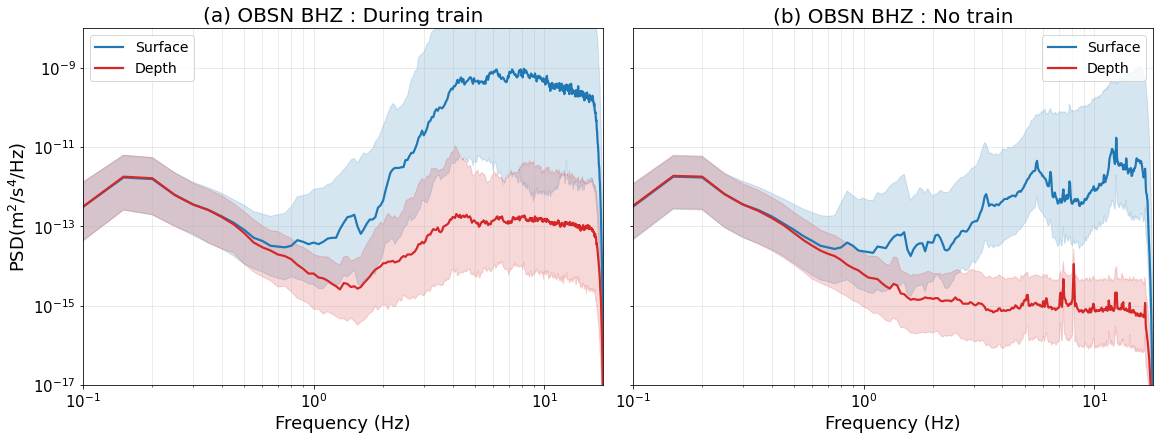

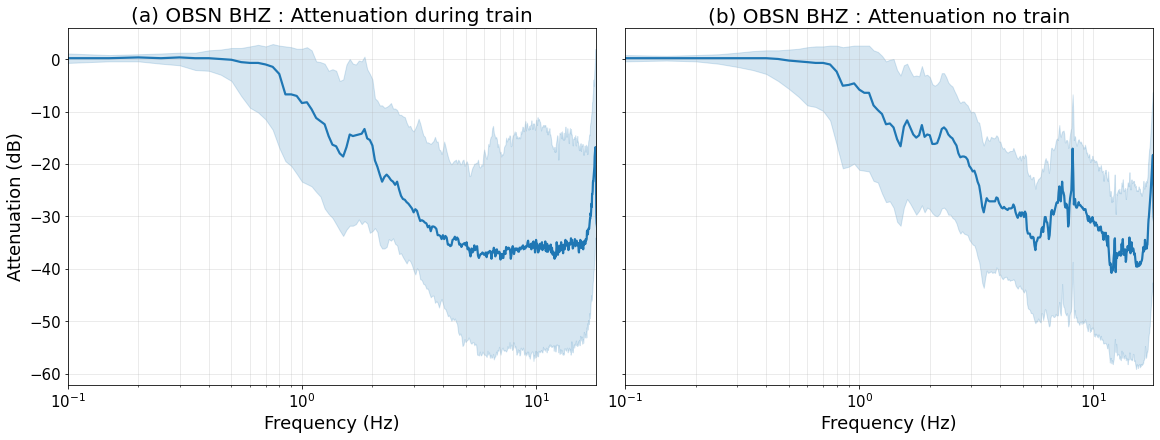

In [2]:
import os
import re
import math
import pickle
import datetime
import numpy as np
import scipy.signal as sp
import matplotlib.pyplot as plt

from obspy import read_inventory, UTCDateTime
from obspy.clients.filesystem.sds import Client
from modules import trainStatsMod

# ============================================================
# Configuration
# ============================================================
rootP2 = '/dcache/etseis/et/EMR/Data'
archiveP2 = Client(rootP2)
stnName = 'OBSN'
compName = 'BHZ'
dateStVec = [338]
yearVec = [2025]
nDays = 1
chunkCoreSec = 7200
edgePadSec = 600

inventory_files = {
    stnName: '/dcache/etseis/et/EMR/Stations/Stations/NL.' + stnName + '.xml',
}
inventories = {sta: read_inventory(path) for sta, path in inventory_files.items()}

# extract the station location and depth
net = inventories[stnName].select(network="NL", station=stnName, location="01", channel=compName)[0]
sta01 = net.stations[0]
cha01 = sta01.channels[0]
cha01Depth = cha01.depth
print("Latitude:", sta01.latitude)
print("Longitude:", sta01.longitude)
print("Elevation (m):", sta01.elevation)

preFiltDefault = [0.05, 0.1, 16, 18]

cfg = {
    "label": stnName + '_' + compName,
    "surface": {
        "station": stnName,
        "network": "NL",
        "location": "00",
        "channel": compName,
        "inventory_key": stnName,
        "use_prefilt": True,
        "pre_filt": preFiltDefault,
        "output_unit": "VEL",
    },
    "underground": {
        "station": stnName,
        "network": "NL",
        "location": "01",
        "channel": compName,
        "inventory_key": stnName,
        "use_prefilt": True,
        "pre_filt": preFiltDefault,
        "output_unit": "VEL",
    },
}


trainParams = {
    "spec_win_sec": 20.0,
    "spec_overlap_frac": 0.5,
    "f_band": (2.0, 8.0),
    "z_thresh": 2.0,
    "min_duration_sec": 20.0,
    "pad_sec": 0.0,
}

# histogram settings
logPsdMin = -24
logPsdMax = -8
nHistBinsPsd = 800
histEdgesPsd = np.linspace(logPsdMin, logPsdMax, nHistBinsPsd + 1)

attDbMin = -80
attDbMax = 40
nHistBinsAtt = 800
histEdgesAtt = np.linspace(attDbMin, attDbMax, nHistBinsAtt + 1)

#output_dir = '/data/gravwav/koley/PSDHistBoreholes/' + stnName + 'Train/'
#output_file = os.path.join(output_dir, 'train_stats_multi_chunk.pkl')

# ============================================================
# Main run block
# ============================================================

day0 = int(dateStVec[0])
year0 = int(yearVec[0])

A = datetime.datetime(year0, 1, 1) + datetime.timedelta(days=day0 - 1)
analysisStart = UTCDateTime(A.year, A.month, A.day)

totalDurationSec = nDays * 86400
nChunks = int(np.ceil(totalDurationSec / chunkCoreSec))

trainStats = None
eventCounter = 0

for chunkIdx in range(nChunks):
    coreStartAbs = chunkIdx * chunkCoreSec
    coreEndAbs = min((chunkIdx + 1) * chunkCoreSec, totalDurationSec)

    coreStart = analysisStart + coreStartAbs
    coreEnd = analysisStart + coreEndAbs

    readStart = coreStart - edgePadSec
    readEnd = coreEnd + edgePadSec

    print(f'chunk {chunkIdx+1}/{nChunks}: core=[{coreStart},{coreEnd}] read=[{readStart},{readEnd}]')

    # --------------------------------------------
    # Read padded traces
    # --------------------------------------------
    xSurf, fs0 = trainStatsMod.fetchCorrectedTrace(archiveP2, cfg["surface"], inventories, readStart, readEnd, preFiltDefault)
    xBh, fs1 = trainStatsMod.fetchCorrectedTrace(archiveP2, cfg["underground"], inventories, readStart, readEnd, preFiltDefault)

    if xSurf is None or xBh is None:
        print('Skipping chunk because one trace is missing')
        continue

    if fs0 != fs1:
        print('Skipping chunk because sampling rates do not match')
        continue

    fs = fs1

    # --------------------------------------------
    # Trim padded read back to core interval
    # --------------------------------------------
    i0 = int(edgePadSec * fs)
    i1 = i0 + int((coreEndAbs - coreStartAbs) * fs)

    if len(xSurf) < i1 or len(xBh) < i1:
        print('Skipping chunk because padded read is too short')
        continue

    xSurfCore = xSurf[i0:i1]
    xBhCore = xBh[i0:i1]
    
    xSurfCoreHp = trainStatsMod.highpass_trace(xSurfCore, fs, f_hp=2.0, order=4)
    xBhCoreHp = trainStatsMod.highpass_trace(xBhCore, fs, f_hp=2.0, order=4)

    # --------------------------------------------
    # Spectrograms and train detection on core
    # --------------------------------------------
    fBh, tSpec, SxxBh, score, maskCols = trainStatsMod.buildTrainMaskFromTrace(xBhCore, fs, trainParams)
    fSf, tSpecSf, SxxSf = trainStatsMod.computeSpectrogram(
        xSurfCore, fs,
        win_sec=trainParams["spec_win_sec"],
        overlap_frac=trainParams["spec_overlap_frac"]
    )
    
    # avoid zeroing the DC component
    if fBh[0] == 0:
        fBh = fBh[1:]
        fSf = fSf[1:]
        SxxBh = SxxBh[1:, :]
        SxxSf = SxxSf[1:, :]
    
    # convert to accleration
    SxxSf = SxxSf * (2 * np.pi * fBh[:, None])**2
    SxxBh = SxxBh * (2 * np.pi * fBh[:, None])**2

    if not np.allclose(fBh, fSf) or not np.allclose(tSpec, tSpecSf):
        print('Skipping chunk because surface/underground spectrogram grids do not match')
        continue
    
    # PSD ratio in dB
    SxxAttDb = 10.0 * np.log10(SxxBh / SxxSf)

    trainIntervals = trainStatsMod.getTrainIntervals(tSpec, maskCols, coreStart)

    # --------------------------------------------
    # Initialize structure after first valid chunk
    # --------------------------------------------
    if trainStats is None:
        meta = {
            "station_surface": cfg["surface"]["station"],
            "location_surface": cfg["surface"]["location"],
            "station_underground": cfg["underground"]["station"],
            "location_underground": cfg["underground"]["location"],
            "channel": cfg["surface"]["channel"],
            "fs": fs,
            "spectrogram_win_sec": trainParams["spec_win_sec"],
            "spectrogram_overlap_frac": trainParams["spec_overlap_frac"],
            "train_band_hz": trainParams["f_band"],
            "z_thresh": trainParams["z_thresh"],
            "min_duration_sec": trainParams["min_duration_sec"],
            "pad_sec": trainParams["pad_sec"],
            "edge_pad_sec": edgePadSec,
            "chunk_core_sec": chunkCoreSec,
            "analysis_start": str(analysisStart),
            "nDays": int(nDays),
        }

        trainStats = trainStatsMod.initializeTrainStatsStruct(fBh, histEdgesPsd, histEdgesAtt, meta=meta)

    # --------------------------------------------
    # Fill event records
    # --------------------------------------------
    for ev0 in trainIntervals:
        ev = trainStatsMod.fillEventStats(
            ev0=ev0,
            event_id=eventCounter,
            chunk_id=chunkIdx,
            score=score,
            f=fBh,
            tSpec=tSpec,
            SxxBh=SxxBh,
            SxxSf=SxxSf,
            SxxAttDb=SxxAttDb,
            xBh=xBhCoreHp,
            xSurf=xSurfCoreHp,
            fs=fs,
            coreStart=coreStart,
            trainBand=trainParams["f_band"]
        )
        trainStats["events"].append(ev)
        eventCounter += 1

    # --------------------------------------------
    # Update histograms
    # --------------------------------------------
    trainStatsMod.updateTrainNoTrainHistograms(
        trainStats=trainStats,
        f=fBh,
        SxxSf=SxxSf,
        SxxBh=SxxBh,
        SxxAttDb=SxxAttDb,
        maskCols=maskCols
    )

# ============================================================
# Finalize after loop
# ============================================================
if trainStats is None:
    raise RuntimeError("No valid chunks were processed.")

for key in ["surface_train", "surface_notrain", "underground_train", "underground_notrain"]:
    trainStatsMod.computePercentilesFromHist(trainStats["histograms"][key], probs=(0.1, 0.5, 0.9), log10_to_linear=True)

for key in ["attenuation_train", "attenuation_notrain"]:
    trainStatsMod.computePercentilesFromHist(trainStats["histograms"][key], probs=(0.1, 0.5, 0.9), log10_to_linear=False)

print(f'Total detected train events = {len(trainStats["events"])}')

# save the trainStats
with open(output_file, 'wb') as f:
    pickle.dump(trainStats, f)

print(f'Saved trainStats to {output_file}')

trainStatsMod.plotTrainNoTrainPSD(trainStats, title_prefix=stnName + ' '+ compName)
trainStatsMod.plotTrainNoTrainAttenuation(trainStats, title_prefix=stnName + ' '+ compName)


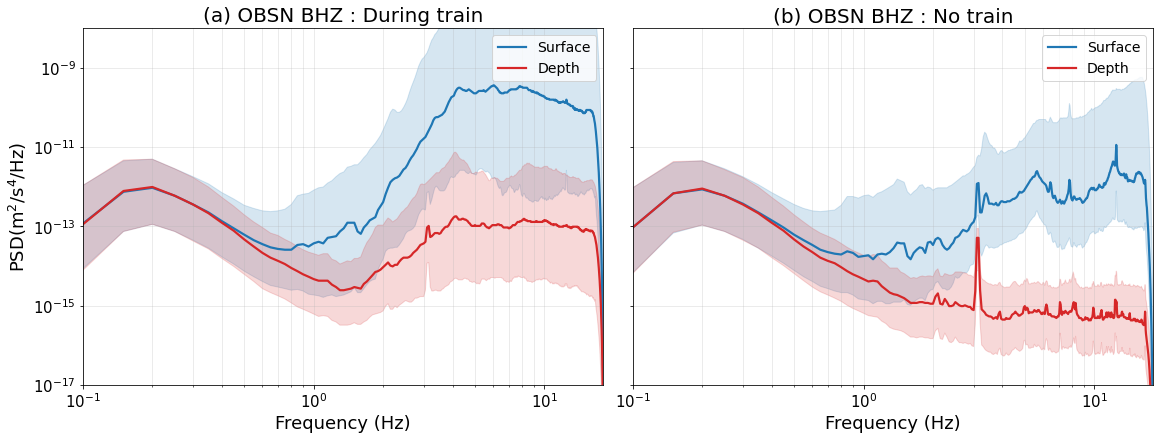

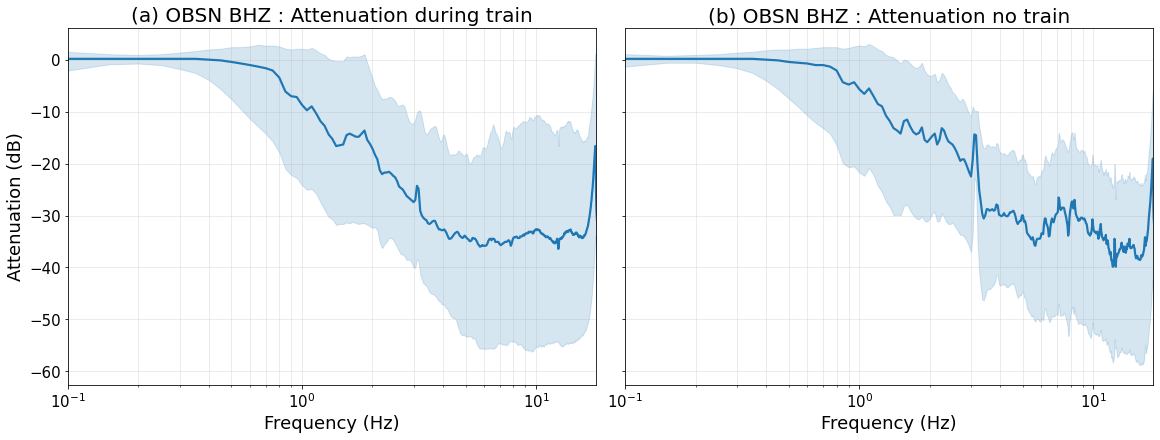

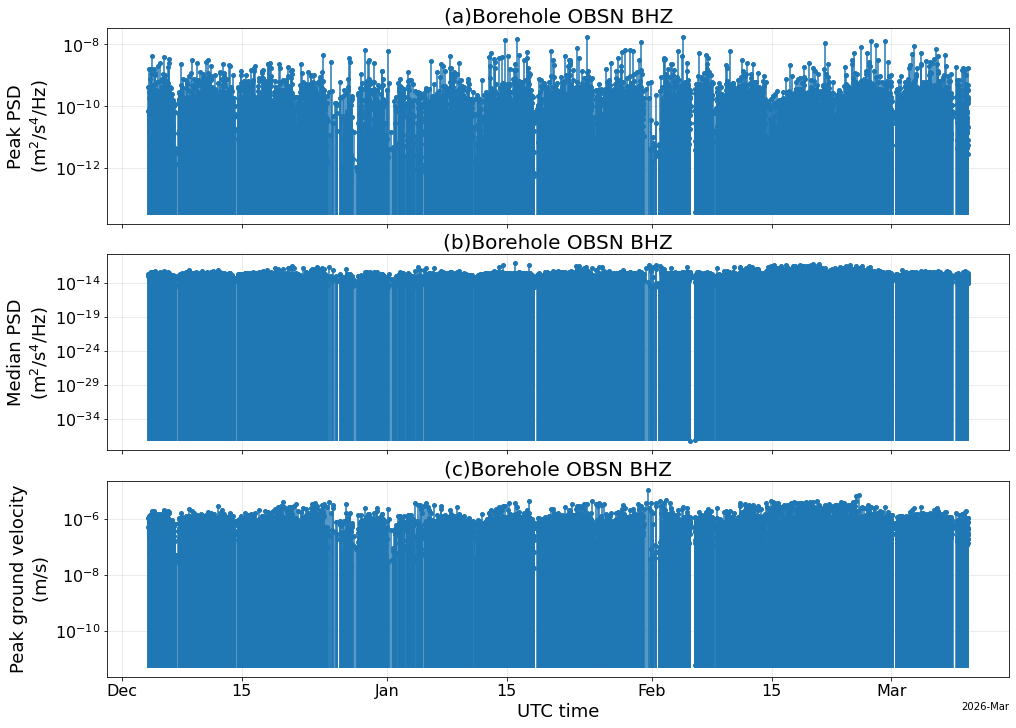

In [95]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from modules import trainStatsMod
    
def plot_trainstats_event_attributes(
    trainstats_pickle,
    y_keys=("bh_peak_psd", "duration_sec", "score_max"),
    y_labels=None,
    title_prefix=None,
    marker='o',
    linestyle='-',
    ms=5,
    lw=1.5,
    figsize=(14, 10),
    sharex=True,
    sort_by_time=True,
    logy_keys=None,
):

    # -----------------------------
    # style
    # -----------------------------
    label_fs = 18
    title_fs = 20
    tick_fs = 16

    if logy_keys is None:
        logy_keys = set()
    else:
        logy_keys = set(logy_keys)

    with open(trainstats_pickle, 'rb') as f:
        trainStats = pickle.load(f)

    events = trainStats.get("events", [])
    meta = trainStats.get("meta", {})

    if len(events) == 0:
        raise ValueError("No events found in trainStats file.")

    if len(y_keys) != 3:
        raise ValueError("Please provide exactly 3 y_keys for the (3,1) subplot layout.")

    # default labels = keys
    if y_labels is None:
        y_labels = list(y_keys)
    if len(y_labels) != 3:
        raise ValueError("y_labels must have the same length as y_keys.")

    # -----------------------------
    # extract event times
    # -----------------------------
    times = []
    for ev in events:
        t = ev.get("start_utc", None)
        if t is None:
            times.append(None)
        else:
            # ObsPy UTCDateTime -> Python datetime
            try:
                times.append(t.datetime)
            except AttributeError:
                times.append(t)

    # optional sorting by time
    valid_idx = [i for i, t in enumerate(times) if t is not None]
    if sort_by_time:
        valid_idx = sorted(valid_idx, key=lambda i: times[i])

    times_sorted = [times[i] for i in valid_idx]

    # -----------------------------
    # helper to pull one attribute
    # -----------------------------
    def get_attr_array(key):
        vals = []
        for i in valid_idx:
            v = events[i].get(key, np.nan)
            if v is None:
                v = np.nan
            vals.append(v)
        return np.asarray(vals, dtype=float)

    # -----------------------------
    # plotting
    # -----------------------------
    fig, axs = plt.subplots(3, 1, figsize=figsize, sharex=sharex, constrained_layout=True)

    panel_labels = ['(a)', '(b)', '(c)']
    if(title_prefix is not None):
        base_title = title_prefix + ' ' + meta.get("station_underground","Train stats") + ' ' + meta.get("channel","Train stats") 
    else:
        base_title = 'Surface ' + meta.get("station_underground","Train stats") + ' ' + meta.get("channel","Train stats")
    #base_title = title_prefix if title_prefix is not None else meta.get("channel", "Train stats")

    for j, (key, ylab) in enumerate(zip(y_keys, y_labels)):
        y = get_attr_array(key)
        
        #axs[j].plot(times_sorted, y, marker=marker, linestyle=linestyle, ms=ms, lw=lw)

        #if key in logy_keys:
        #    positive = np.isfinite(y) & (y > 0)
        #    if np.any(positive):
        #        axs[j].set_yscale('log')
        
        finite = np.isfinite(y)
        x_plot = np.array(times_sorted)[finite]
        y_plot = y[finite]

        if key in logy_keys:
            positive = y_plot > 0
            x_plot = x_plot[positive]
            y_plot = y_plot[positive]

        if len(y_plot) > 0:
            axs[j].set_yscale('log')
            ymin = np.nanmin(y_plot) * 0.8
            axs[j].vlines(x_plot, ymin, y_plot, linewidth=lw)
            axs[j].plot(x_plot, y_plot, 'o', ms=4)
        else:
            axs[j].vlines(x_plot, 0, y_plot, linewidth=lw)
            axs[j].plot(x_plot, y_plot, 'o', ms=4)
        
        axs[j].set_ylabel(ylab, fontsize=label_fs)
        axs[j].set_title(f'{panel_labels[j]}{base_title}', fontsize=title_fs)
        axs[j].grid(True, alpha=0.3)
        axs[j].tick_params(axis='both', labelsize=tick_fs)

    axs[-1].set_xlabel('UTC time', fontsize=label_fs)

    # datetime formatting
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    axs[-1].xaxis.set_major_locator(locator)
    axs[-1].xaxis.set_major_formatter(formatter)

    # optional overall figure title
    #fig.suptitle(base_title, fontsize=title_fs + 2)

    plt.show()

stnName = 'OBSN'
compName = 'BHZ'
fName = '/data/gravwav/koley/PSDHistBoreholes/OBSNTrain/train_stats_multi_chunk.pkl'

#open the trainnstats file and plot the PSD and attenuation
with open(fName, 'rb') as f:
        trainStats = pickle.load(f)
trainStatsMod.plotTrainNoTrainPSD(trainStats, title_prefix=stnName + ' '+ compName)
trainStatsMod.plotTrainNoTrainAttenuation(trainStats, title_prefix=stnName + ' '+ compName)        

plot_trainstats_event_attributes(
    fName,
    y_keys=("bh_peak_psd", "bh_band_median_psd", "bh_pgv"),
    y_labels = ("Peak PSD\n" + r"($\mathrm{m}^2/\mathrm{s}^4/\mathrm{Hz}$)",
                "Median PSD\n" + r"($\mathrm{m}^2/\mathrm{s}^4/\mathrm{Hz}$)",
                "Peak ground velocity\n" + r"($\mathrm{m}/\mathrm{s}$)",),
    title_prefix='Borehole',
    marker='o',
    linestyle='-',
    ms=5,
    lw=1.5,
    figsize=(14, 10),
    sharex=True,
    sort_by_time=True,
    logy_keys=("bh_peak_psd","bh_band_median_psd","bh_pgv"),
)

TEUV Train = [64, 57, 47, 25, 40, 47, 58, 59, 48, 50, 29, 38, 51, 59, 50, 54, 52, 26, 42, 37, 32, 6, 10, 20, 10, 35, 34, 23, 7, 25, 17, 17, 31, 35, 40, 43, 42, 41, 23, 29, 46, 49, 57, 57, 53, 30, 38, 43, 51, 55, 52, 53, 30, 47, 46, 59, 61, 66, 1, 41, 54, 50, 33, 50, 50, 27, 46, 52, 58, 55, 59, 11, 5, 42, 42, 53, 52, 58, 52, 28, 49, 62, 55, 60, 64, 58, 30, 48, 57, 54, 55, 53, 49, 38, 42]
OBSN Train = [69, 62, 61, 27, 46, 56, 64, 70, 58, 52, 28, 54, 54, 64, 66, 60, 56, 26, 44, 43, 38, 6, 11, 21, 12, 36, 36, 29, 6, 29, 18, 17, 37, 37, 51, 46, 46, 45, 22, 37, 49, 58, 61, 69, 53, 32, 42, 51, 61, 63, 65, 59, 32, 52, 56, 64, 73, 76, 1, 1, 52, 60, 59, 38, 56, 52, 27, 52, 59, 68, 65, 72, 12, 5, 51, 49, 59, 66, 64, 65, 32, 49, 64, 62, 70, 68, 65, 32, 54, 69, 67, 73, 64, 58, 40, 52]


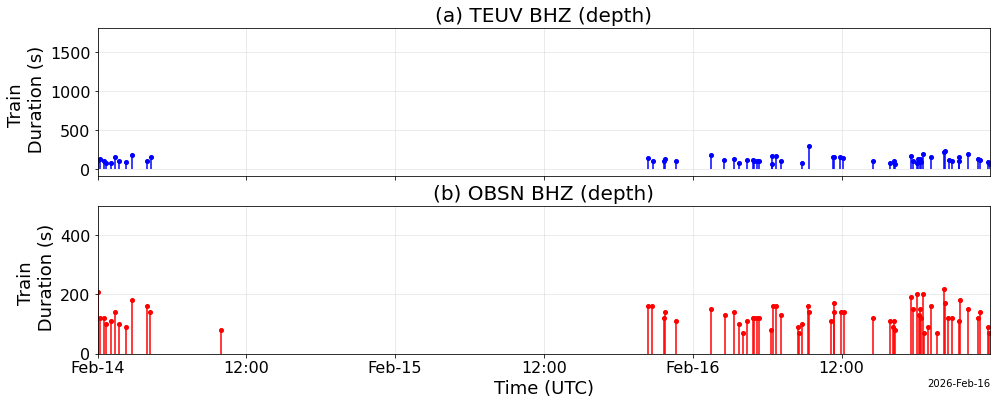

In [106]:
# make comparitive plots of OBSN and TEUV train statistics
import datetime as dt
fOBSN = '/data/gravwav/koley/PSDHistBoreholes/OBSNTrain/train_stats_multi_chunk.pkl'
fTEUV = '/data/gravwav/koley/PSDHistBoreholes/TEUVTrain/train_stats_multi_chunk.pkl'
label_fs = 18
title_fs = 20
tick_fs = 16

with open(fOBSN, 'rb') as f:
    trainStatsOBSN = pickle.load(f)

with open(fTEUV, 'rb') as f:
    trainStatsTEUV = pickle.load(f)

eventsOBSN = trainStatsOBSN.get("events", [])
metaOBSN = trainStatsOBSN.get("meta", {})

eventsTEUV = trainStatsTEUV.get("events", [])
metaTEUV = trainStatsTEUV.get("meta", {})

nEventsTEUV = len(eventsTEUV)
nEventsOBSN = len(eventsOBSN)

obsnStruct = {"startTrain":[], "durTrain":[], "tC":[], "medianPSD":[], "peakPSD":[], "pgv":[]}
teuvStruct = {"startTrain":[], "durTrain":[], "tC":[], "medianPSD":[], "peakPSD":[], "pgv":[]}

tC = 0
dateStart = eventsTEUV[0]['start_utc']
startDay = dateStart.julday
for i in range(0,nEventsTEUV):
    if(eventsTEUV[i]['duration_sec']>60):
        teuvStruct["startTrain"].append(eventsTEUV[i]['start_utc'])
        teuvStruct["durTrain"].append(eventsTEUV[i]['duration_sec'])
        teuvStruct["medianPSD"].append(eventsTEUV[i]['bh_band_median_psd'])
        teuvStruct["peakPSD"].append(eventsTEUV[i]['bh_peak_psd'])
        teuvStruct["pgv"].append(eventsTEUV[i]['bh_pgv'])
        tC = tC+1
        currDate = eventsTEUV[i]['start_utc']
        currDay = currDate.julday
        if(currDay != startDay):
            teuvStruct["tC"].append(tC-1)
            startDay = currDay
            tC = 1

# fill the last day
teuvStruct["tC"].append(tC-1)

tC = 0
dateStart = eventsOBSN[0]['start_utc'].julday
for i in range(0,nEventsOBSN):
    if(eventsOBSN[i]['duration_sec']>60):
        obsnStruct["startTrain"].append(eventsOBSN[i]['start_utc'])
        obsnStruct["durTrain"].append(eventsOBSN[i]['duration_sec'])
        obsnStruct["medianPSD"].append(eventsOBSN[i]['bh_band_median_psd'])
        obsnStruct["peakPSD"].append(eventsOBSN[i]['bh_peak_psd'])
        obsnStruct["pgv"].append(eventsOBSN[i]['bh_pgv'])
        tC = tC+1
        currDay = eventsOBSN[i]['start_utc'].julday
        if(currDay != dateStart):
            obsnStruct["tC"].append(tC-1)
            dateStart = currDay
            tC = 1
# fill the last day
obsnStruct["tC"].append(tC-1)

teuvTPlot = [t.datetime for t in teuvStruct["startTrain"]]
obsnTPlot = [t.datetime for t in obsnStruct["startTrain"]]

                   
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)

fig, ax = plt.subplots(2,1,figsize=(16,6),sharex=True)

ax[0].vlines(teuvTPlot,0,teuvStruct["durTrain"],'b')
ax[0].plot(teuvTPlot, teuvStruct["durTrain"], 'bo', ms=4)
ax[0].xaxis.set_major_locator(locator)
ax[0].xaxis.set_major_formatter(formatter)
ax[0].set_ylabel("Train \n Duration (s)",fontsize=label_fs)
ax[0].set_title("(a) TEUV BHZ (depth)", fontsize=title_fs)
ax[0].tick_params(axis='both', labelsize=tick_fs)
#ax[0].set_ylim(0,60)
ax[0].grid(True, alpha=0.3)

ax[1].vlines(obsnTPlot,0,obsnStruct["durTrain"],'r')
ax[1].plot(obsnTPlot, obsnStruct["durTrain"], 'ro', ms=4)
ax[1].xaxis.set_major_locator(locator)
ax[1].xaxis.set_major_formatter(formatter)
ax[1].set_ylabel("Train \n Duration (s)",fontsize=label_fs)
ax[1].set_xlabel("Time (UTC)", fontsize = label_fs)
ax[1].set_title("(b) OBSN BHZ (depth)", fontsize=title_fs)
ax[1].tick_params(axis='both', labelsize=tick_fs)
#ax[1].set_ylim(0,60)
ax[1].grid(True, alpha=0.3)

ax[1].set_xlim(
    dt.datetime(2026, 2, 14, 0, 0, 0),
    dt.datetime(2026, 2, 16, 23, 59, 59)
)
ax[1].set_ylim(0,500)
print('TEUV Train = ' + str(teuvStruct["tC"]))
print('OBSN Train = ' + str(obsnStruct["tC"]))

In [100]:
i

5972